## Exploratory Models AqSolDB vs AqSolDB Curated

In [1]:
""" Importing all required libraries """
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit import RDLogger
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



### Featurisation and Cleaning Function

In [22]:
def generate_and_clean_features(df, smiles_col='SMILES', target_col='Solubility'):
    # Import the updated fingerprint generator
    from rdkit.Chem import rdFingerprintGenerator
    
    # Extract valid SMILES and Target
    X_smiles = df[smiles_col].values
    y = df[target_col].values
    
    fps = []
    desc_list = []
    valid_indices = []
    
    # Get all RDKit descriptor names
    desc_names = [n[0] for n in Descriptors._descList]
    
    # Initialize the modern Morgan Generator (radius 2, 2048 bits)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    
    print("1. Generating RDKit Descriptors and Morgan Fingerprints...")
    for i, smiles in enumerate(tqdm(X_smiles)):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Generate Morgan Fingerprint using the new generator
            fp = mfpgen.GetFingerprint(mol)
            fps.append(list(fp))
            
            # RDKit Descriptors
            descs = [f(mol) for _, f in Descriptors._descList]
            desc_list.append(descs)
            
            valid_indices.append(i)
            
    # Convert to DataFrames
    df_fp = pd.DataFrame(fps, columns=[f'MF_{i}' for i in range(2048)])
    df_desc = pd.DataFrame(desc_list, columns=desc_names)
    
    # Combine features
    X = pd.concat([df_desc, df_fp], axis=1)
    y_clean = y[valid_indices]
    
    # Ensure column names are compatible with XGBoost
    X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)
    
    print("\n2. Cleaning Features...")
    
    # a. Remove IPC column
    if 'Ipc' in X.columns:
        X = X.drop(columns=['Ipc'])
        print("- Removed 'Ipc' column.")
        
    # b. Fix Infinity Values
    # RDKit can generate 'inf' for certain descriptors. We must replace them with NaN for XGBoost.
    # We use numpy to safely check and replace inf across the dataframe.
    X = X.replace([np.inf, -np.inf], np.nan)
    print("- Converted any 'inf' values to 'NaN' for XGBoost compatibility.")
        
    # c. Keep NaNs
    print("- Retaining all NaN columns and rows as requested.")
    
    return X, y_clean

### Model Training and Plotting Function

In [26]:
def train_and_evaluate_xgboost(X, y, dataset_name, color):
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Note: StandardScaler has been removed because it fails when processing NaNs.
    # XGBoost handles NaNs natively and does not require feature scaling.
    
    # Model Training (XGBoost)
    print(f"\nTraining XGBoost for {dataset_name}...")
    xgb = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
)
    
    xgb.fit(X_train, y_train)
    
    # Predictions
    y_pred = xgb.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    diff = np.abs(y_test - y_pred)
    pct_07 = (diff <= 0.7).mean() * 100
    pct_10 = (diff <= 1.0).mean() * 100
    
    # Output metrics below cell
    print(f"--- Performance Metrics: {dataset_name} ---")
    print(f"R2: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"% within 0.7: {pct_07:.2f}%")
    print(f"% within 1.0: {pct_10:.2f}%")
    
    # Actual vs Predicted Scatter Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolor='white')
    
    # Plot perfect prediction line
    min_val = min(np.min(y_test), np.min(y_pred))
    max_val = max(np.max(y_test), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')
    
    plt.xlabel('Actual Solubility, LogS')
    plt.ylabel('Predicted Solubility, LogS')
    
    # Add stats to legend
    legend_label = f"XGBoost Test Set\nR2 = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}\n% w/in 0.7 = {pct_07:.1f}%\n% w/in 1.0 = {pct_10:.1f}%"
    plt.scatter([], [], alpha=0, label=legend_label)
    plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    
    plt.show()
    
    return xgb

### AqSolDB Model

1. Generating RDKit Descriptors and Morgan Fingerprints...


  3%|▎         | 307/9982 [00:03<01:30, 106.94it/s][10:54:36] WARNING: not removing hydrogen atom without neighbors
[10:54:36] WARNING: not removing hydrogen atom without neighbors
  4%|▍         | 429/9982 [00:04<01:21, 117.36it/s][10:54:37] WARNING: not removing hydrogen atom without neighbors
[10:54:37] WARNING: not removing hydrogen atom without neighbors
[10:54:37] WARNING: not removing hydrogen atom without neighbors
[10:54:37] WARNING: not removing hydrogen atom without neighbors
  6%|▋         | 640/9982 [00:07<01:53, 82.28it/s] [10:54:40] WARNING: not removing hydrogen atom without neighbors
[10:54:40] WARNING: not removing hydrogen atom without neighbors
  7%|▋         | 695/9982 [00:08<02:01, 76.28it/s][10:54:40] WARNING: not removing hydrogen atom without neighbors
[10:54:40] WARNING: not removing hydrogen atom without neighbors
  8%|▊         | 796/9982 [00:09<01:35, 95.86it/s][10:54:41] WARNING: not removing hydrogen atom without neighbors
[10:54:41] WARNING: not removing


2. Cleaning Features...
- Removed 'Ipc' column.
- Converted any 'inf' values to 'NaN' for XGBoost compatibility.
- Retaining all NaN columns and rows as requested.

Training XGBoost for AqSolDB...
--- Performance Metrics: AqSolDB ---
R2: 0.842
RMSE: 0.926
MAE: 0.619
% within 0.7: 70.34%
% within 1.0: 82.11%


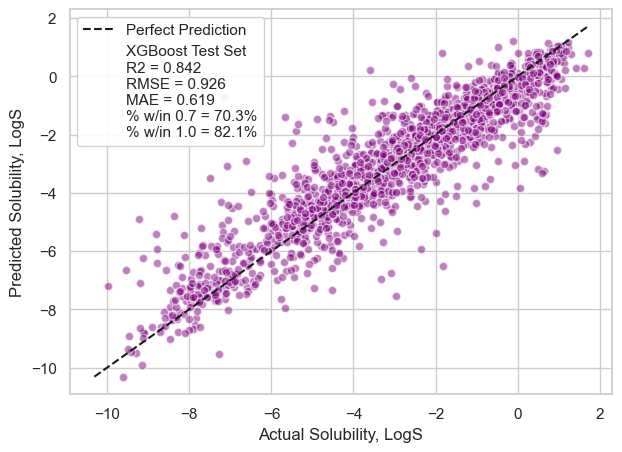

In [ ]:
# 1. Load and filter original AqSolDB
df_aqsoldb = pd.read_csv('path/to/AqSolDB')
df_aqsoldb = df_aqsoldb.dropna(subset=["SMILES", "Solubility"])
df_aqsoldb = df_aqsoldb.drop_duplicates(subset=['SMILES'])


# 2. Generate and Clean Features
X_aq, y_aq = generate_and_clean_features(df_aqsoldb, smiles_col='SMILES', target_col='Solubility')

# 3. Train XGBoost and plot performance
model_aq = train_and_evaluate_xgboost(X_aq, y_aq, "AqSolDB", color="purple")

### AqSolDB Curated Model

1. Generating RDKit Descriptors and Morgan Fingerprints...


  3%|▎         | 239/8047 [00:02<01:06, 118.01it/s][10:57:25] WARNING: not removing hydrogen atom without neighbors
[10:57:25] WARNING: not removing hydrogen atom without neighbors
[10:57:25] WARNING: not removing hydrogen atom without neighbors
[10:57:25] WARNING: not removing hydrogen atom without neighbors
  5%|▌         | 414/8047 [00:03<01:10, 107.82it/s][10:57:27] WARNING: not removing hydrogen atom without neighbors
[10:57:27] WARNING: not removing hydrogen atom without neighbors
  8%|▊         | 678/8047 [00:06<01:01, 119.28it/s][10:57:29] WARNING: not removing hydrogen atom without neighbors
[10:57:29] WARNING: not removing hydrogen atom without neighbors
 12%|█▏        | 964/8047 [00:09<01:52, 63.09it/s] [10:57:33] WARNING: not removing hydrogen atom without neighbors
[10:57:33] WARNING: not removing hydrogen atom without neighbors
 13%|█▎        | 1033/8047 [00:11<02:41, 43.32it/s][10:57:34] WARNING: not removing hydrogen atom without neighbors
[10:57:34] WARNING: not removi


2. Cleaning Features...
- Removed 'Ipc' column.
- Converted any 'inf' values to 'NaN' for XGBoost compatibility.
- Retaining all NaN columns and rows as requested.

Training XGBoost for AqSolDBc...
--- Performance Metrics: AqSolDBc ---
R2: 0.873
RMSE: 0.805
MAE: 0.559
% within 0.7: 73.91%
% within 1.0: 84.41%


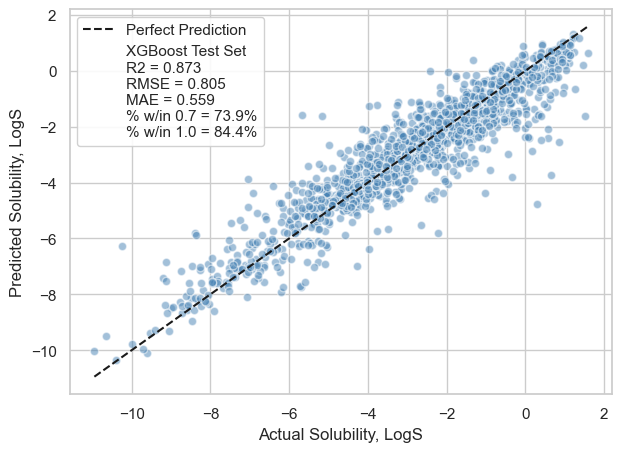

In [ ]:
# 1. Load and filter curated AqSolDBc
df_aqsoldbc = pd.read_csv('path/to/AqSolDBc)
df_aqsoldbc = df_aqsoldbc.dropna(subset=["SMILES", "ExperimentalLogS"])
df_aqsoldbc = df_aqsoldbc.drop_duplicates(subset=['SMILES'])


# 2. Generate and Clean Features
X_aqc, y_aqc = generate_and_clean_features(df_aqsoldbc, smiles_col='SMILES', target_col='ExperimentalLogS')

# 3. Train XGBoost and plot performance
model_aqc = train_and_evaluate_xgboost(X_aqc, y_aqc, "AqSolDBc", color="steelblue")